# Synthetic data generation
> Synthetic data generation

In [ ]:
#| default_exp preprocessing.zero_degree_solder_pin.synthetic_data

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2


In [ ]:
#| export
import sys
from pathlib import Path
import random


In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
sys.path.append(str(CV_TOOLS))


In [ ]:
#| export
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))


In [ ]:
#| export
from cv_tools.imports import *
from cv_tools.core import *
from dotenv import load_dotenv


In [ ]:
#| export
load_dotenv(dotenv_path=f'/home/ai_sintercra/homes/hasan/projects/git_data/new_test/new_test/.env')

False

In [ ]:
#| export
CURRETNT_NB='/home/ai_sintercra/homes/hasan/projects/git_data/new_test/nbs'

In [ ]:
#| eval: false
from platform import system
if system() == 'Windows':
    core_path = Path(r'E:\CurrentTrainingData20240812_trn_val/trn_masks')
else:
    core_path = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/trn_masks')

MODEL_NAME='ETPD-WAR1_03.keras'
mask_path = Path(
    core_path.parent, 
    f'Incoming_1B_Loetstift/Incoming_1B_Loetstift_unzip/main_im2_cropped_masks/{MODEL_NAME}/passed/masks'
    )
rect_mask_path = Path(mask_path.parent, 'rotated_rect_masks')
im_path = Path(mask_path.parent, 'images')
sn_im_path = Path(im_path.parent, 'sn_pins')
sn_msk_path = Path(im_path.parent, 'sn_masks')
sn_ov_path = Path(im_path.parent, 'sn_overlays')


In [ ]:
sm_sn_im = sn_im_path.ls()[0]


In [ ]:

sm_sn_im_name = Path(sm_sn_im).name
msk_name = sm_sn_im_name.replace('pin', 'msk')
sm_sn_msk = Path(sn_msk_path, msk_name)
sm_sn_msk_img = read_img(sm_sn_msk)

In [ ]:
sm_sn_msk.is_file()

True

In [ ]:
sm_sn_msk_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [ ]:
BLEND_SIGMA = 3.0
DARK_SIDE_BRIGHTNESS = 50
SIDE='left'
SIDE_WIDTH_RATIO = 0.25

In [ ]:
img = read_img(sm_sn_im)

In [ ]:
def get_pin_box(
    img=None,
    msk=None,
    pin_bbox_ratio=0.4,
    pin_bbox_ratio_h=0.8,
    ):

    if msk is not None:
        msk = msk.astype(np.uint8)
        cntrs = find_contours_binary(msk)
        if len(cntrs) > 0:
            cntr = cntrs[0]
            
            pin_bbox = cv2.boundingRect(cntr)
            return pin_bbox
        else:
            print('No contours found')
            return None
    else:
        # Fallback to image-based estimation if mask is empty
        h, w = img.shape[:2]
        pin_w = int(w * pin_bbox_ratio)
        pin_h = int(h * pin_bbox_ratio_h)
        pin_x = (w - pin_w) // 2
        pin_y = (h - pin_h) // 2
        pin_bbox = (pin_x, pin_y, pin_w, pin_h)
        return pin_bbox


In [ ]:
def add_synthetic_shading(
    input_image,
    pin_mask,  # Binary mask of pin region
    dark_sides=["left"],
    blend_sigma=3.0,
    dark_side_brightness=50,
    side_width_ratio=0.10 #0.25 # Width of dark side as ratio of pin width
):
    """
    Add synthetic dark shading to a pin region using a binary mask.
    
    Args:
        input_image (np.ndarray): Input grayscale image
        pin_mask (np.ndarray): Binary mask indicating pin region
        dark_sides (list): List of sides to make dark ["left", "right", "top", "bottom"]
        blend_sigma (float): Gaussian blur sigma for blending
        dark_side_brightness (int): Target brightness for dark sides (0-255)
        side_width_ratio (float): Width of dark side as ratio of pin width
    
    Returns:
        np.ndarray: Image with synthetic shading applied only to pin region
    """
    # Ensure input image is grayscale
    if len(input_image.shape) > 2:
        input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
    
    # Get pin bounding box from mask
    pin_bbox = get_pin_box(pin_mask)
    if pin_bbox is None:
        return input_image
        
    x, y, w, h = pin_bbox
    
    # Convert pin mask to float32
    pin_mask = pin_mask.astype(np.float32)
    
    # Create dark mask only for pin region
    dark_mask = np.zeros_like(input_image, dtype=np.float32)
    side_width = int(w * side_width_ratio)
    
    for side in dark_sides:
        if side == "left":
            cv2.rectangle(dark_mask, 
                        (x, y),
                        (x + side_width, y + h),
                        1.0, -1)
        elif side == "right":
            cv2.rectangle(dark_mask,
                        (x + w - side_width, y),
                        (x + w, y + h),
                        1.0, -1)
        elif side == "top":
            cv2.rectangle(dark_mask,
                        (x, y),
                        (x + w, y + 3*side_width),
                        1.0, -1)
        elif side == "bottom":
            cv2.rectangle(dark_mask,
                        (x, y + h - 3*side_width),
                        (x + w, y + h),
                        1.0, -1)
    
    # Blur the dark mask for smooth transition
    dark_mask = cv2.GaussianBlur(dark_mask, (0, 0), blend_sigma)
    
    # Ensure shading only affects pin region by using the actual pin mask
    dark_mask = dark_mask * pin_mask
    
    # Convert input image to float32 for calculations
    img_float = input_image.astype(np.float32)
    
    # Create darkened version only for pin region
    darkened = np.minimum(img_float, dark_side_brightness)
    
    # Blend original and darkened versions using the mask
    result = img_float * (1 - dark_mask) + darkened * dark_mask
    
    # Convert back to uint8
    result = np.clip(result, 0, 255).astype(np.uint8)
    
    return result

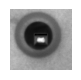

In [ ]:
show_(add_synthetic_shading(img, sm_sn_msk_img, dark_sides=['top'], side_width_ratio=0.20))

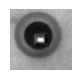

In [ ]:
show_(add_synthetic_shading(img, sm_sn_msk_img, dark_sides=['right'], side_width_ratio=0.10))

>  Synthetic data generation

- left should be 0.10
- right should be 0.10
- top should be 0.20
- bottom should be 0.20



# Rotate Pin Region

In [ ]:
#| export
def rotate_pin_region(
    input_image:np.ndarray, # Input image
    pin_mask:np.ndarray,# Binary mask of the pin region
    rotation_angle:int # Angle for rotation[90, 180, 270, 360]
    ):
    """
    Rotate the pin region of an image and its corresponding mask by specified angle.
    
    Args:
        input_image (np.ndarray): Input image
        pin_mask (np.ndarray): Binary mask of the pin region
        rotation_angle (int): Rotation angle in degrees (90, 180, 270, 360)
    
    Returns:
        tuple: (rotated_image, rotated_mask)
    """
    # Ensure rotation angle is valid
    #assert rotation_angle in [90, 180, 270, 360], "Rotation angle must be 90, 180, 270, or 360 degrees"
    
    # Get the bounding box of the pin region
    y_indices, x_indices = np.where(pin_mask > 0)
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    
    # Extract the pin region from the image
    pin_region = input_image[y_min:y_max+1, x_min:x_max+1]
    pin_mask_region = pin_mask[y_min:y_max+1, x_min:x_max+1]
    
    # Calculate rotation center
    center = (pin_region.shape[1] // 2, pin_region.shape[0] // 2)
    
    # Get rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
    
    # Rotate both the pin region and its mask
    rotated_pin = cv2.warpAffine(pin_region, rotation_matrix, (pin_region.shape[1], pin_region.shape[0]))
    rotated_mask = cv2.warpAffine(pin_mask_region, rotation_matrix, (pin_region.shape[1], pin_region.shape[0]))
    
    # Create copies of the original image and mask
    result_image = input_image.copy()
    result_mask = pin_mask.copy()
    
    # Paste the rotated regions back
    result_image[y_min:y_max+1, x_min:x_max+1] = rotated_pin
    result_mask[y_min:y_max+1, x_min:x_max+1] = rotated_mask
    
    return result_image, result_mask


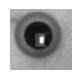

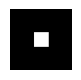

In [ ]:

# Example usage:
rotated_img, rotated_mask = rotate_pin_region(img, sm_sn_msk_img, 90)
show_(rotated_img)
# show_(rotated_img)
show_(rotated_mask)


Drawing line
Drawing shape


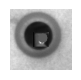

In [ ]:

# Example usage:
shaded_img = add_shading_on_pin_top(rotated_img, rotated_mask)
show_(shaded_img)



# Image generation from eberhard

In [ ]:
#| export
def add_blurred_shapes(image, mask, num_shapes=20, min_size=10, max_size=30, blur_kernel=(5, 5)):
    assert mask.shape == image.shape, "Mask must have the same dimensions as the image"
    
    result = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the darkest color from the mask region
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    darkest_color = np.min(masked_image[np.nonzero(masked_image)]) #- 10
    
    for _ in range(num_shapes):
        start_point = get_start_point(image, contours[0])
        
        # Use the darkest color found in the mask region as an integer
        color = int(darkest_color)
        
        # Randomly select number of vertices between 3 and 7 for polygon shape
        num_vertices = random.randint(4, 7)
        points = []
        for _ in range(num_vertices):
            angle = random.uniform(0, 2 * np.pi)
            radius = random.randint(min_size, max_size)
            x = int(start_point[0] + radius * np.cos(angle))
            y = int(start_point[1] + radius * np.sin(angle))
            points.append((x, y))
        
        shape_canvas = np.zeros(image.shape, dtype=np.uint8)
        points = np.array(points, np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(shape_canvas, [points], color)
        
        # Apply a large Gaussian blur for smooth blending
        blurred_shape = cv2.GaussianBlur(shape_canvas, (31, 31), 0)
        
        # Create a mask for smooth alpha blending
        alpha_mask = cv2.GaussianBlur(-blurred_shape, (31, 31), 0)
        alpha_mask = (alpha_mask.astype(float) / 255)  # Normalize to [0, 1] range
        
        # Apply alpha blending
        result = (1 - alpha_mask) * result + alpha_mask * blurred_shape
    
    return result.astype(np.uint8)

# Example usage:
# result_image = add_blurred_shapes(img, msk)
# show_(result_image)


In [ ]:
#| export
def generate_and_save_images(
        im_path:Path, # path to images
        mask_path:Path, # path to masks
        num_generations:int, # number of generations
        dest_folder:Path, # destination folder,
		num_shapes:int=1 # number of shapes to add
):
    # Create destination image and mask paths
    dest_im_path = dest_folder / 'images'
    dest_mask_path = dest_folder / 'masks'
    dest_im_path.mkdir(parents=True, exist_ok=True)
    dest_mask_path.mkdir(parents=True, exist_ok=True)

    for i in tqdm(im_path.ls(),total=len(im_path.ls()), desc='Generating images'):
        name_ = i.name
        img = read_img(i)
        msk = read_img(Path(mask_path, name_))
        
        for j in range(num_generations):
            rs = add_blurred_shapes(img, msk, num_shapes=num_shapes)
            
            # Create new filenames with index
            new_im_name = f"{i.stem}_{j}{i.suffix}"
            new_msk_name = f"{i.stem}_{j}{i.suffix}"
            #print(new_im_name, new_msk_name)
            #break

            try:
                if dest_folder is not None:
                    cv2.imwrite(str(dest_im_path / new_im_name), rs)
                    cv2.imwrite(str(dest_mask_path / new_msk_name), msk)
            except Exception as e:
                print(e)
                print(i)
                continue
            

# Example usage:
# generate_and_save_images(trn_im_path, trn_msk_path, 5, Path('/path/to/destination/folder'))


In [ ]:
#| export
def get_start_point(img, cntr):
    center_y, center_x = img.shape[0]//2, img.shape[1]//2
    distances = [np.sqrt((pt[0][0]-center_x)**2 + (pt[0][1]-center_y)**2) for pt in cntr]
    min_idx = np.argmin(distances)
    max_idx = np.argmax(distances)
    rand_idx = np.random.randint(0, len(distances))
    start_point_idx = np.random.choice([min_idx, max_idx, rand_idx])
    return tuple(cntr[start_point_idx][0])

In [ ]:
#| export
# Add shading only on the pin top region
def add_shading_on_pin_top(image, mask, intensity_range=(0.2, 0.6), line_prob=1, shape_prob=0.3):
    """
    Add random shading effects on the bright parts of the pin region.
    
    Args:
        image (np.ndarray): Input image
        mask (np.ndarray): Binary mask of the pin region
        intensity_range (tuple): Range of shading intensity (min, max)
        line_prob (float): Probability of adding a line
        shape_prob (float): Probability of adding a random shape
        
    Returns:
        np.ndarray: Image with added shading effects
    """
    result = image.copy()
    
    # Find bright regions in the pin area
    bright_mask = (image > 200) & (mask > 0)
    if not np.any(bright_mask):
        return result
    
    # Get coordinates of bright regions
    y_indices, x_indices = np.where(bright_mask)
    
    # Randomly decide whether to add a line
    if np.random.random() < line_prob:
        # Choose random start and end points
        start_idx = np.random.randint(0, len(x_indices))
        end_idx = np.random.randint(0, len(x_indices))
        
        start_pt = (x_indices[start_idx], y_indices[start_idx])
        end_pt = (x_indices[end_idx], y_indices[end_idx])
        
        # Draw line with random intensity
        intensity = np.random.uniform(*intensity_range)
        cv2.line(result, start_pt, end_pt, (intensity * 255, intensity * 255, intensity * 255), 
                thickness=np.random.randint(1, 3))
    return result
    

6


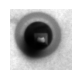

In [ ]:
# mask and img
#sm_sn_msk_img, img
show_(add_blurred_shapes(img, sm_sn_msk_img, num_shapes=1, min_size=10, max_size=12))

Drawing line


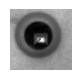

In [ ]:
show_(add_shading_on_pin_top(img, sm_sn_msk_img))

In [ ]:
#| export
def gen_rotation(
    num_generations:int,# Number of generations
    input_image:np.ndarray, # Input image
    pin_mask:np.ndarray,# Binary mask of the pin region
    im_name:str, # Name of the image
    im_save_path:Path, # Path to save the image
    msk_save_path:Path # Path to save the mask
    ):
    for i in range(num_generations):
        angle = get_angle()
        rotated_img, rotated_mask = rotate_pin_region(
            input_image, 
            pin_mask, 
            rotation_angle=angle)
        # Save or process the rotated images and masks with timestamp
        timestamp = datetime.now().strftime('%Y%m%d%H%M%S%f')
        save_path = f'{im_name}_rotation_{i}_angle_{angle}_{timestamp}.png'
        if im_save_path is not None:
            cv2.imwrite(f'{im_save_path}/{save_path}', rotated_img)
        if msk_save_path is not None:
            cv2.imwrite(f'{msk_save_path}/{save_path}', rotated_mask)


In [ ]:
from nbdev.showdoc import show_doc

In [ ]:
show_doc(rotate_pin_region)

---

### rotate_pin_region

>      rotate_pin_region (input_image, pin_mask, rotation_angle)

*Rotate the pin region of an image and its corresponding mask by specified angle.

Args:
    input_image (np.ndarray): Input image
    pin_mask (np.ndarray): Binary mask of the pin region
    rotation_angle (int): Rotation angle in degrees (90, 180, 270, 360)

Returns:
    tuple: (rotated_image, rotated_mask)*

In [ ]:
img = read_img(sm_sn_im)
msk = read_img(sm_sn_msk)

In [ ]:
gen_rotation(
    num_generations=10, 
    input_image=img, 
    pin_mask=sm_sn_msk_img, 
    im_name=Path(sm_sn_im).stem
    )

VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_0_angle_360_20250410154113244770.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_1_angle_270_20250410154113244770.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_2_angle_360_20250410154113245811.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_3_angle_360_20250410154113245811.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_4_angle_360_20250410154113245811.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_5_angle_270_20250410154113245811.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_rotation_6_angle_360_20250410154113245811.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_

In [ ]:
np.random.randint(1,4)

2

In [ ]:
np.random.randint(1, 5)

1

In [ ]:
pin_fns = sn_im_path.ls()
pins_ = np.random.choice(pin_fns, 100)

In [ ]:
sn_msk_path.name

'sn_masks'

In [ ]:
fns = get_name_(pins_)

In [ ]:
gen_sn_im_path

Path('E:/CurrentTrainingData20240812_trn_val/gen_sn_im')

In [ ]:
gen_sn_im_path = Path(core_path.parent, 'gen_sn_im')
gen_sn_msk_path = Path(core_path.parent, 'gen_sn_msk')
Path(gen_sn_im_path).mkdir(parents=True, exist_ok=True)
Path(gen_sn_msk_path).mkdir(parents=True, exist_ok=True)

In [ ]:
#| export
def get_angle():
    if np.random.random() < 1:
        return np.random.choice([90, 270, 360])
    else:
        return np.random.randint(0, 361)


In [ ]:
#| export
def gen_line(
    num_generations:int, # Number of generations
    input_image:np.ndarray, # Input image
    pin_mask:np.ndarray, # Binary mask of the pin region
    im_name:str, # Name of the image
    im_save_path:Path=None, # Path to save the image
    msk_save_path:Path=None # Path to save the mask
    ):
    'Generate line shading on the pin top region'
    for i in range(num_generations):
        image_ = add_shading_on_pin_top(
            input_image, 
            pin_mask, 
            intensity_range=(0.2, 0.6), 
            line_prob=1, 
            shape_prob=0.3)
        mask_ = pin_mask

        timestamp = datetime.now().strftime('%Y%m%d%H%M%S%f')
        save_path = f'{im_name}_{i}_line_{timestamp}.png'
        if im_save_path is not None:
            cv2.imwrite(f'{im_save_path}/{save_path}', image_)
        if msk_save_path is not None:
            cv2.imwrite(f'{msk_save_path}/{save_path}', mask_)


In [ ]:
gen_line(
    num_generations=10, 
    input_image=img, 
    pin_mask=msk, 
    im_name=Path(sm_sn_im).stem
    )


Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_0_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_1_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_2_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_3_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_4_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_5_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_6_line_20250410155428506280.png
Drawing line
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image

In [ ]:
#| export
def gen_shading(
    num_generations:int, # Number of generations
    input_image:np.ndarray, # Input image
    pin_mask:np.ndarray, # Binary mask of the pin region
    im_name:str, # Name of the image
    im_save_path:Path=None, # Path to save the image
    msk_save_path:Path=None # Path to save the mask
    ):
    'Generate shading on the pin top region'
    for i in range(num_generations):
        if np.random.random() < 0.7:
            num_shapes = 1
        else:
            num_shapes = np.random.randint(1,5)
        image_ = add_blurred_shapes(
            input_image, 
            pin_mask, 
            num_shapes=num_shapes, 
            min_size=2, 
            max_size=8, 
            blur_kernel=(5, 5))
        mask_ = pin_mask
        timestamp = datetime.now().strftime('%Y%m%d%H%M%S%f')
        save_path = f'{im_name}_{i}_shading_num_shapes_{num_shapes}_{timestamp}.png'
        if im_save_path is not None:
            cv2.imwrite(f'{im_save_path}/{save_path}', image_)
        if msk_save_path is not None:
            cv2.imwrite(f'{msk_save_path}/{save_path}', mask_)



In [ ]:
gen_shading(
    num_generations=10, 
    input_image=img, 
    pin_mask=msk, 
    im_name=Path(sm_sn_im).stem
    
    )


VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_0_shading_num_shapes_1_20250410162443346899.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_1_shading_num_shapes_1_20250410162443348419.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_2_shading_num_shapes_2_20250410162443349417.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_3_shading_num_shapes_1_20250410162443350419.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_4_shading_num_shapes_1_20250410162443351416.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_5_shading_num_shapes_3_20250410162443352988.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2_pin_0_6_shading_num_shapes_1_20250410162443352988.png
VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pa

In [ ]:
#| export
def do_generation(
    case_name:str, # Case name
    image_save_path:Path, # Path to save the image
    mask_save_path:Path, # Path to save the mask
    input_image:np.ndarray, # Input image
    pin_mask:np.ndarray, # Binary mask of the pin region
    im_name:str, # Name of the image
    num_generations:int=30, # Number of generations
    **kwargs
    ):
    if case_name == 'rotation':
        gen_rotation(
            num_generations=num_generations, 
            input_image=input_image, 
            pin_mask=pin_mask, 
            im_name=im_name,
            im_save_path=image_save_path,
            msk_save_path=mask_save_path
            )
            # Generate new random angle for next iteration
    elif case_name == 'line':
        gen_line(
            num_generations=num_generations, 
            input_image=input_image, 
            pin_mask=pin_mask, 
            im_name=im_name,
            im_save_path=image_save_path,
            msk_save_path=mask_save_path
            )
    elif case_name == 'shading':
        gen_shading(
            num_generations=num_generations, 
            input_image=input_image, 
            pin_mask=pin_mask, 
            im_name=im_name,
            im_save_path=image_save_path,
            msk_save_path=mask_save_path
            )

In [ ]:
#| export
@call_parse
def main_(
    pin_path:Param("Path to input pin images", Path) = Path("."), 
    msk_path:Param("Path to input mask images", Path) = Path("."), 
    gen_im_path:Param("Path to save generated images", Path) = Path("."), 
    gen_msk_path:Param("Path to save generated masks", Path) = Path("."),
    num_generations:Param("Number of generations per image", int) = 10,
    select_files:Param("Select files to generate", int) = 10,
    ):
    pin_fns = pin_path.ls()
    pins_ = np.random.choice(pin_fns, select_files)  # Select 100 random pin images
    fns = get_name_(pins_)
    total_images = len(fns) * 3 * num_generations  # 3 cases (rotation, shading, line) per image
    print(f'{"#"*100}')
    print(f"Will generate {total_images} total images ({len(fns)} base images × 3 cases × {num_generations} generations)")
    print(f'{"#"*100}')
    
    for i in tqdm(fns, total=len(fns), desc='Generating images'):
        pin_fn = Path(pin_path, i)
        msk_fn = Path(msk_path, i.replace('pin', 'msk'))
        img = read_img(pin_fn)
        msk = read_img(msk_fn)
        for case in ['rotation', 'shading', 'line']:
            do_generation(
                case_name=case,
                im_name=Path(i).stem,
                input_image=img,
                pin_mask=msk,
                image_save_path=gen_im_path,
                mask_save_path=gen_msk_path,
                num_generations=num_generations
            )

## Split data into training, validation and test set

In [ ]:
src_im_path =Path(mask_path.parent, 'gen_im_full')
src_msk_path =Path(mask_path.parent, 'gen_msk_full')

In [ ]:
images, masks = src_im_path.ls(), src_msk_path.ls()

In [ ]:
def get_synthetic_data_type(name):
    if 'rotation' in name:
        return 'rotation'
    elif 'shading' in name:
        return 'shading'
    elif 'line' in name:
        return 'line'
    else:
        return 'unknown'




In [ ]:
df = pd.DataFrame()
df['fns'] = get_name_(images)
df['synthetic_data_type'] = df['fns'].apply(get_synthetic_data_type)

In [ ]:
from sklearn.model_selection import train_test_split
trian_test_split = train_test_split(df, test_size=0.2, random_state=42, stratify=df['synthetic_data_type'])

In [ ]:
trn_df, test_df = trian_test_split
trn_images = trn_df['fns'].values
val_images = test_df['fns'].values

In [ ]:
def parallel_copy_files(
    src_im_path,  # Source image path
    src_msk_path,  # Source mask path
    dst_im_path,  # Destination image path
    dst_msk_path,  # Destination mask path
    image_names  # List of image names to copy
    ):
    """Copy images and masks in parallel using joblib"""
    from joblib import Parallel, delayed
    from shutil import copy2
    
    def copy_single_file(im_name):
        # Copy image
        src_im = src_im_path/im_name
        dst_im = dst_im_path/im_name
        copy2(src_im, dst_im)
        
        # Copy corresponding mask
        src_msk = src_msk_path/im_name
        dst_msk = dst_msk_path/im_name
        copy2(src_msk, dst_msk)
        
        return im_name

    # Use all available CPU cores
    results = Parallel(n_jobs=-1)(delayed(copy_single_file)(im_name) for im_name in image_names)
    return results


In [ ]:
core_path_zero = Path(core_path.parent, 'training_zero_degree_solder_pin')
trn_path = Path(core_path_zero, 'train')
val_path = Path(core_path_zero, 'val')
test_path = Path(core_path_zero, 'test')
trn_im_path = Path(trn_path, 'images')
trn_msk_path = Path(trn_path, 'masks')
val_im_path = Path(val_path, 'images')
val_msk_path = Path(val_path, 'masks')
test_im_path = Path(test_path, 'images')
test_msk_path = Path(test_path, 'masks')



# 
trn_path.mkdir(parents=True, exist_ok=True)
val_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)
trn_im_path.mkdir(parents=True, exist_ok=True)
trn_msk_path.mkdir(parents=True, exist_ok=True)
val_im_path.mkdir(parents=True, exist_ok=True)
val_msk_path.mkdir(parents=True, exist_ok=True)
test_im_path.mkdir(parents=True, exist_ok=True)
test_msk_path.mkdir(parents=True, exist_ok=True)




In [ ]:

# Copy training data
print("Copying training data...")
parallel_copy_files(src_im_path, src_msk_path, trn_im_path, trn_msk_path, trn_images)

# Copy validation data
print("Copying validation data...")
parallel_copy_files(src_im_path, src_msk_path, val_im_path, val_msk_path, val_images)


Copying training data...


FileNotFoundError: [WinError 53] The network path was not found

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('41_preprocessing.zero_degree_solder_pin.synthetic_data.ipynb')

ValueError: '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\nbs\\26_model_evaluation.new_model.ipynb' is not in the subpath of '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\new_test\\nbs'